In [8]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [9]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [13]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam
import functools


from IPython.display import display

In [11]:
def timeit(func):
    """Decorator to measure execution time of a function and print a friendly summary."""

    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - start
        mins, secs = divmod(elapsed, 60)
        hours, mins = divmod(mins, 60)
        time_str = (
            f"{int(hours)}h {int(mins)}m {secs:.2f}s"
            if hours
            else f"{int(mins)}m {secs:.2f}s"
            if mins
            else f"{secs:.2f}s"
        )
        print(f"\n🚀 Script completed successfully in {time_str}!")
        return result

    return wrapper


def prep_pc():
    # Quiet TensorFlow logging
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    import tensorflow as tf

    # GPU memory growth
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)


class TimeStopping(Callback):
    """Stop training when exceeding a time limit (in seconds)."""

    def __init__(self, max_seconds=300):
        super().__init__()
        self.max_seconds = max_seconds
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.max_seconds:
            print(
                f"\n⏱️ Stopping training - time limit of {self.max_seconds} seconds reached."
            )
            self.model.stop_training = True


def eval_classification(model, X, y, name="model", labels=None, plot=False):
    """Evaluate and optionally plot a confusion matrix."""
    preds = np.rint(model.predict(X))
    print(f"\n=== {name} ===")
    print(classification_report(y, preds, target_names=labels))

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    score_df = pd.DataFrame(
        index=[name],
        data={
            "Accuracy": [accuracy_score(y, preds)],
            "Precision": [precision_score(y, preds)],
            "Recall": [recall_score(y, preds)],
            "F1 Score": [f1_score(y, preds)],
            "FPR": [fp / (fp + tn) if (fp + tn) > 0 else np.nan],
            "FNR": [fn / (fn + tp) if (fn + tp) > 0 else np.nan],
        },
    )

    if plot:
        ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
        plt.title(name)
        plt.show()

    return score_df


def plot_history(history, plot=False):
    """Plot training & validation metrics from a Keras History.
    Epoch axis is 1-based and corresponds to the actual epochs run (may be < max_epochs if early-stopping).
    """
    if not plot:
        return

    # Determine number of epochs actually run
    first_metric = next(m for m in history.history.keys() if not m.startswith("val_"))
    n_epochs = len(history.history[first_metric])
    epochs = range(1, n_epochs + 1)

    for metric in history.history:
        if metric.startswith("val_"):
            continue
        plt.plot(epochs, history.history[metric], label=metric)
        val_metric = f"val_{metric}"
        if val_metric in history.history:
            plt.plot(epochs, history.history[val_metric], label=val_metric)
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(metric)
        plt.xticks(list(epochs))
        plt.legend()
        plt.grid(True)
        plt.show()


### Classification:
To evaluate the model's performance, the F1 Score is used. It is suitable for phishing detection because it strikes a balance between precision and recall, considering both false positives and false negatives, rather than focusing on one aspect alone. Unlike accuracy, it treats imbalanced datasets well and prevents incorrect performance conclusions. By encapsulating both types of error within a single metric, F1 provides a better understanding of the model's performance and confidence.

### Pseudo Code

FOR each layer_config in layer_configs:
  FOR each epoch_count in epochs_list:
    FOR each min_delta in min_deltas:
      FOR each patience_value in patiences:
        Build sequential model
        Add input + hidden layers with relu
        Add sigmoid output layer
        Compile with Adam, binary_crossentropy
        Apply EarlyStopping + TimeStopping
        Train on X_train, validate on X_val
        Evaluate on both sets using F1 Score, Accuracy, Precision, Recall
        If best F1, save model and config


In [20]:
# --- Load Data ---
df_train = pd.read_csv("Split_Data/Model_Ready/train.csv")
X_train = df_train.drop(columns="label")
y_train = df_train["label"]
df_val = pd.read_csv("Split_Data/Model_Ready/val.csv")
X_val = df_val.drop(columns="label")
y_val = df_val["label"]
df_test = pd.read_csv("Split_Data/Model_Ready/test.csv")
X_test = df_test.drop(columns="label")
y_test = df_test["label"]

# --- Hyperparameter Space ---
layer_configs = [[64], [64, 64], [64, 128, 64], [256, 128, 128, 256]]
epochs_list = [50, 100, 200, 500]
min_deltas = [0.0, 0.001]
patiences = [3, 5, 7, 9]
dropout_rates = [0.3, 0.5]

best_f1 = -1
best_model = None
best_history = None
best_config = None
all_scores = []
labels = ["No Phishing Email", "Phishing Email"]

In [19]:
X_test

,url_count,distinct_url_count,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,...,pca_131,pca_132,pca_133,pca_134,pca_135,pca_136,pca_137,pca_138,pca_139,pca_140
0,1,1,-6.953137,0.361287,4.175816,8.490240,6.791227,-0.773947,-5.484492,-5.169023,...,0.543769,-0.633982,0.742418,-0.636185,0.114270,-0.847610,0.843119,0.414016,-0.217837,0.607597
1,4,4,0.159706,-11.285174,9.169180,6.543233,6.811182,-0.153121,-10.975491,-7.988378,...,0.985052,-0.193631,-0.429054,-0.168540,0.057418,-0.417760,0.182566,0.549962,1.058468,-0.050882
2,1,1,-1.079615,-26.427681,3.056866,7.365059,4.605896,-4.732379,-14.196447,-8.479948,...,0.064529,1.156663,-1.163231,2.478732,1.628148,-1.135290,-0.657964,1.576158,-1.502458,-0.516789
3,0,0,-4.882329,-2.645093,8.788615,9.604267,7.560277,2.131892,-9.539961,-8.715062,...,0.327524,-0.470499,-0.137281,-0.237015,-0.029183,-0.429444,0.022653,-0.011650,0.758216,-0.828705
4,0,0,-8.376190,2.455021,9.427036,12.533369,8.930398,5.499210,-9.001257,-5.755036,...,-0.222767,-0.765501,-0.330948,-0.215923,0.116756,-0.867090,0.613880,-0.465363,-0.144448,0.145352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52787,0,0,-2.318036,9.672186,4.156797,0.418605,2.553891,-1.918131,1.940369,0.034755,...,-0.385978,0.034070,0.599455,0.018140,0.382520,-0.558495,-0.132668,0.373708,-0.139043,-0.148826
52788,0,0,4.540076,13.119678,1.932115,-5.271192,0.760730,-8.913156,-9.203839,5.747170,...,-0.485812,0.018926,-0.853562,0.822117,-0.666964,0.004846,-0.296973,1.540308,0.628679,-0.044993
52789,0,0,-3.037026,8.523153,12.060723,6.265901,3.086341,4.998071,-11.466384,10.087847,...,1.350301,0.483773,2.767285,1.446802,-0.129647,0.572530,-0.389596,-0.302929,-1.748293,0.486408
52790,0,0,0.259640,8.502898,10.037804,-6.980301,2.865456,-3.419100,-3.945061,-1.071457,...,0.908466,1.284475,-0.005505,-1.079786,0.465681,-0.418334,-0.654284,-0.816169,-0.692183,0.487347


In [ ]:
df_test = pd.read_csv("Split_Data/Model_Ready/test.csv")
X_test = df_train.drop(columns="label")
y_test = df_train["label"]

### Build de Model

In [ ]:
# --- Grid Search ---
for layers in layer_configs:
    for epochs in epochs_list:
        for min_delta in min_deltas:
            for patience in patiences:
                for dropout_rate in dropout_rates:
                    config_desc = (
                        f"layers={layers}, epochs={epochs}, min_delta={min_delta}, "
                        f"patience={patience}, dropout_rate={dropout_rate}"
                    )
                    print(f"\nConfig: {config_desc}")

                    # Build model
                    model = Sequential(
                        [
                            Dense(
                                layers[0],
                                activation="relu",
                                input_shape=(X_train.shape[1],),
                            ),
                            Dropout(dropout_rate),
                            *[
                                layer
                                for units in layers[1:]
                                for layer in (
                                    Dense(units, activation="relu"),
                                    Dropout(dropout_rate),
                                )
                            ],
                            Dense(1, activation="sigmoid"),
                        ]
                    )

                    model.compile(
                        optimizer=Adam(learning_rate=1e-3),
                        loss="binary_crossentropy",
                        metrics=[
                            tf.keras.metrics.BinaryAccuracy(name="acc"),
                            tf.keras.metrics.Precision(name="precision"),
                            tf.keras.metrics.Recall(name="recall"),
                            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
                            tf.keras.metrics.AUC(curve="PR",  name="pr_auc"),
                        ],
                    )

                    early_stopping = EarlyStopping(
                        monitor="val_loss",
                        min_delta=min_delta,
                        patience=patience,
                        restore_best_weights=True,
                        verbose=1,
                        mode="min",
                    )
                    time_stopping = TimeStopping(max_seconds=300)

                    history = model.fit(
                        X_train,
                        y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=32,
                        callbacks=[early_stopping, time_stopping],
                        verbose=2,
                    )

                    # Collect metrics without plotting
                    plot_history(history, plot=False)
                    train_scores = eval_classification(
                        model,
                        X_train,
                        y_train,
                        name=f"train {config_desc}",
                        labels=labels,
                        plot=False,
                    )
                    val_scores = eval_classification(
                        model,
                        X_val,
                        y_val,
                        name=f"val {config_desc}",
                        labels=labels,
                        plot=False,
                    )

                    all_scores.append(pd.concat([train_scores, val_scores]))

                    val_f1 = val_scores.iloc[0]["F1 Score"]
                    if val_f1 > best_f1:
                        best_f1 = val_f1
                        best_model = model
                        best_history = history
                        best_config = {
                            "layers": layers,
                            "epochs": epochs,
                            "min_delta": min_delta,
                            "patience": patience,
                            "dropout_rate": dropout_rate,
                            "val_f1_score": val_f1,
                        }

# --- Report & Save ---
print("\n🏆 Best Model Configuration:")
for k, v in best_config.items():
    print(f"{k}: {v}")

best_model.save("best_mlp_model.h5")
print("\n📁 Best model saved as 'best_mlp_model.h5'")

all_results_df = pd.concat(all_scores)
all_results_df.to_csv("mlp_model_results.csv", index=True)
print("Results saved to mlp_model_results.csv")

# --- Final Plots for Best Model ---
print("\n📊 Training History of Best Model:")
plot_history(best_history, plot=True)

print("\n🧪 Confusion Matrix & Metrics on Best Validation Set:")
eval_classification(
    best_model,
    X_val,
    y_val,
    name="Best Model on Validation",
    labels=labels,
    plot=True,
)



Config: layers=[64], epochs=50, min_delta=0.0, patience=3, dropout_rate=0.3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.9289 - loss: 0.2034 - val_accuracy: 0.9602 - val_loss: 0.1166
Epoch 2/50


In [ ]:
# Filter only validation results
val_results = all_results_df[all_results_df.index.str.contains("val")]

# Sort by F1 Score in descending order
val_results_sorted = val_results.sort_values(by="F1 Score", ascending=False)

# Display the top results
print("🔝 Top Validation Results by F1 Score:")
display(val_results_sorted.head(10))

In [21]:
model = tf.keras.models.load_model("best_mlp_model.h5", compile=False)

In [22]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [23]:
results = model.evaluate(X_test, y_test, verbose=0)
metrics = dict(zip(model.metrics_names, results))
print(metrics)


{'loss': 0.12303826212882996, 'compile_metrics': 0.9562344551086426}


              precision    recall  f1-score   support

      Benign       0.96      0.95      0.95      7986
       Phish       0.95      0.96      0.96      8511

    accuracy                           0.96     16497
   macro avg       0.96      0.96      0.96     16497
weighted avg       0.96      0.96      0.96     16497



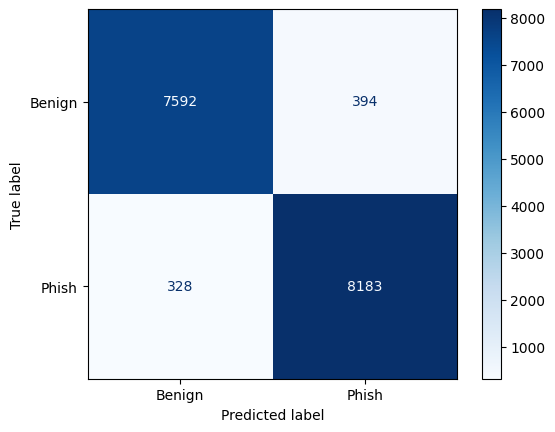

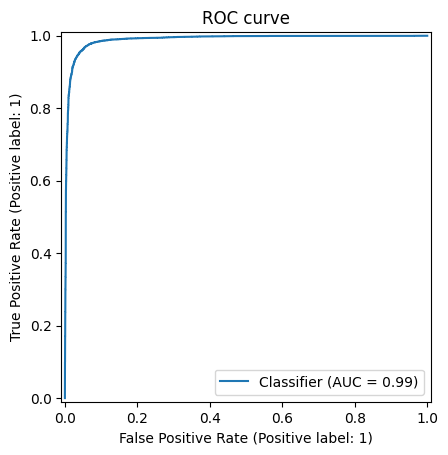

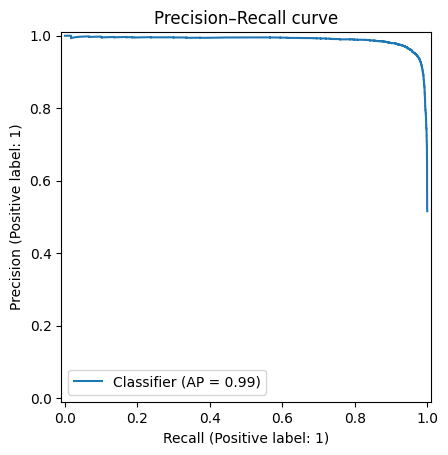

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)     # default threshold

print(classification_report(y_test, y_pred, target_names=["Benign","Phish"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign","Phish"]).plot(cmap="Blues")
plt.show()

# ROC & PR curves
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC curve"); plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision–Recall curve"); plt.show()
